In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [4]:
Nt=192

In [5]:
gsq=0.050000
beta=1.0/gsq

In [6]:
masses_=[]

In [7]:
T=16
Nt=96 # 240

In [8]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

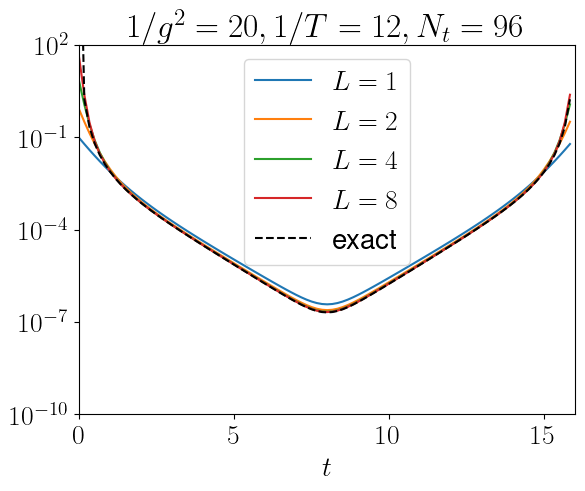

In [9]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [10]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [11]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [12]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

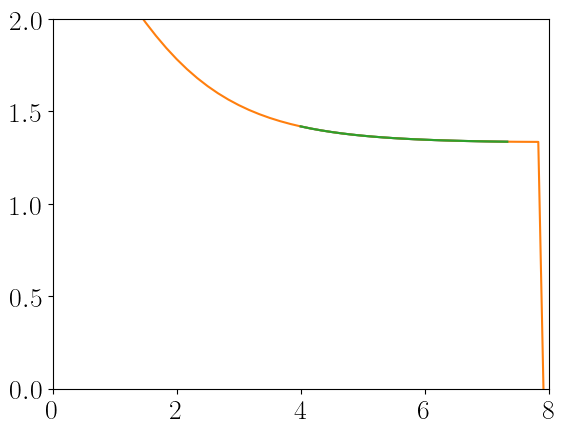

In [13]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [14]:
masses_.append([1, Nt, opt[0][0]])

In [15]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [16]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

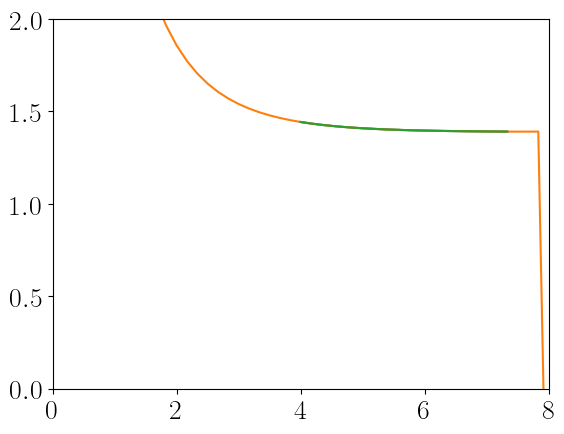

In [17]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [18]:
masses_.append([2, Nt, opt[0][0]])

In [19]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [20]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

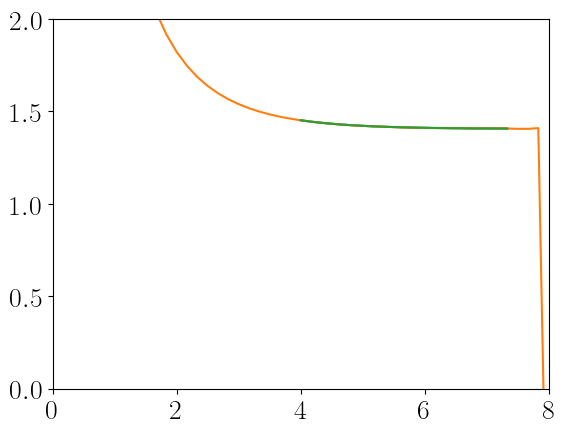

In [21]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [22]:
masses_.append([4, Nt, opt[0][0]])

In [23]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [24]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

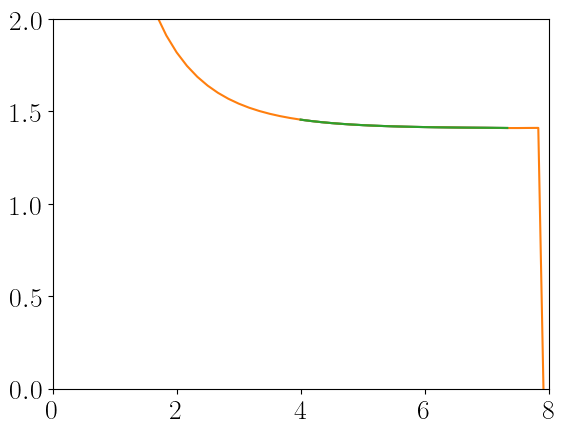

In [25]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [26]:
masses_.append([8, Nt, opt[0][0]])

In [27]:
T=16
Nt=144 # 240

In [28]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

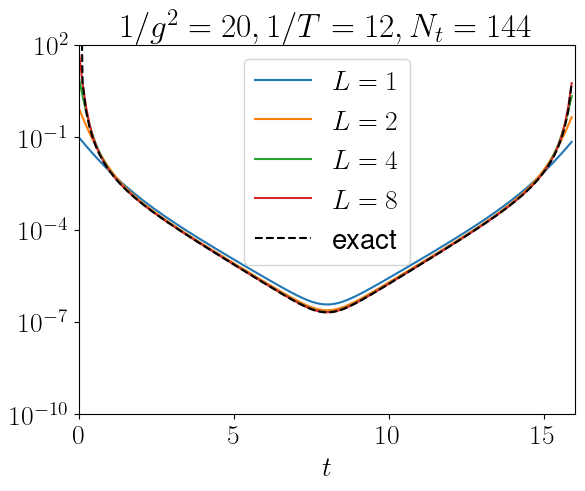

In [29]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [30]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [31]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [32]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

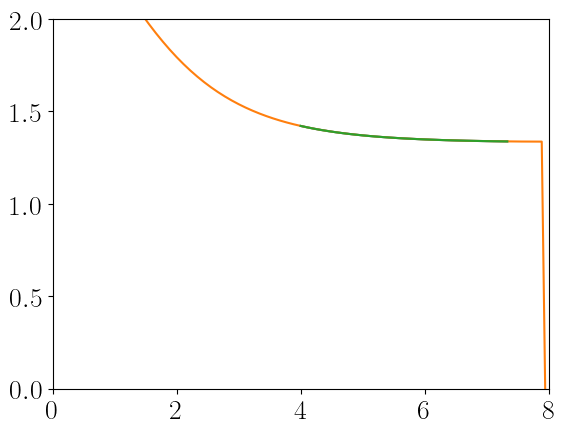

In [33]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [34]:
masses_.append([1, Nt, opt[0][0]])

In [35]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [36]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

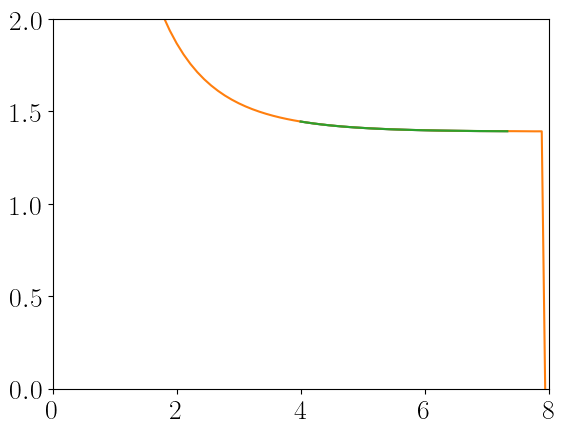

In [37]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [38]:
masses_.append([2, Nt, opt[0][0]])

In [39]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [40]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

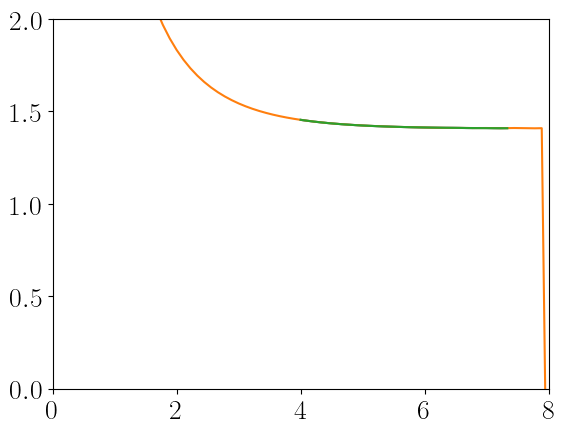

In [41]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [42]:
masses_.append([4, Nt, opt[0][0]])

In [43]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [44]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

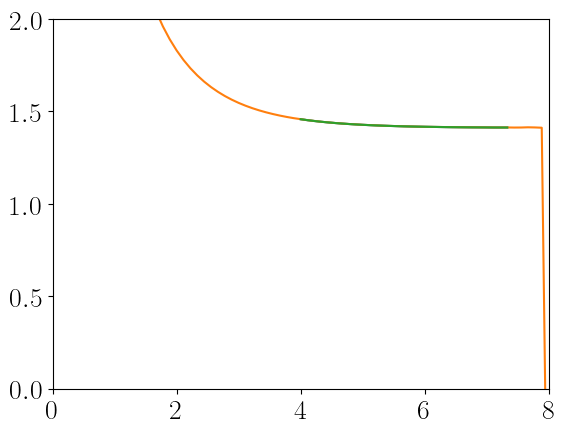

In [45]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [46]:
masses_.append([8, Nt, opt[0][0]])

In [47]:
T=16
Nt=192 # 240

In [48]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

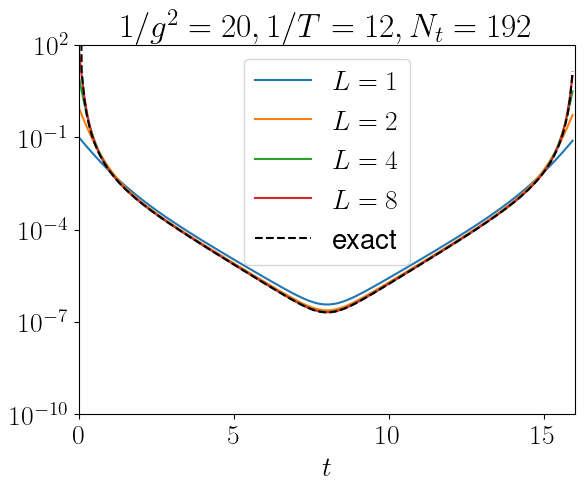

In [49]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [50]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [51]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [52]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

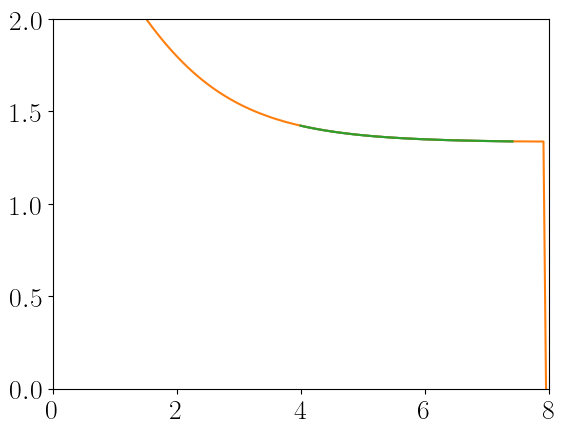

In [53]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [54]:
masses_.append([1, Nt, opt[0][0]])

In [55]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [56]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

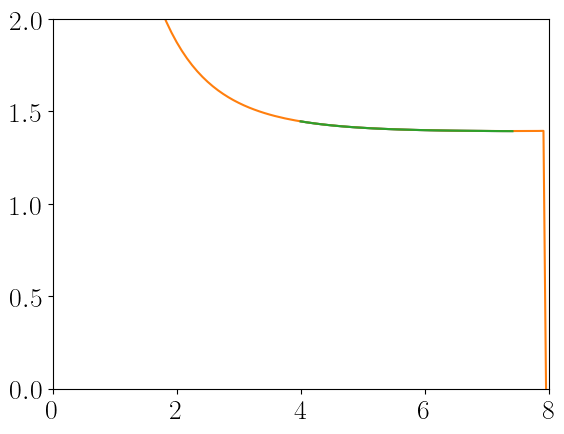

In [57]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [58]:
masses_.append([2, Nt, opt[0][0]])

In [59]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [60]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

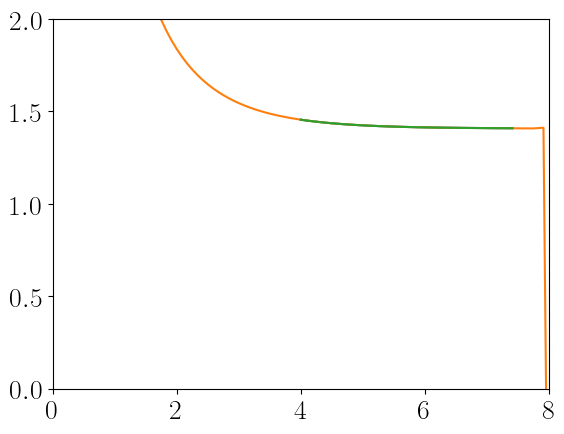

In [61]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [62]:
masses_.append([4, Nt, opt[0][0]])

In [63]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [64]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

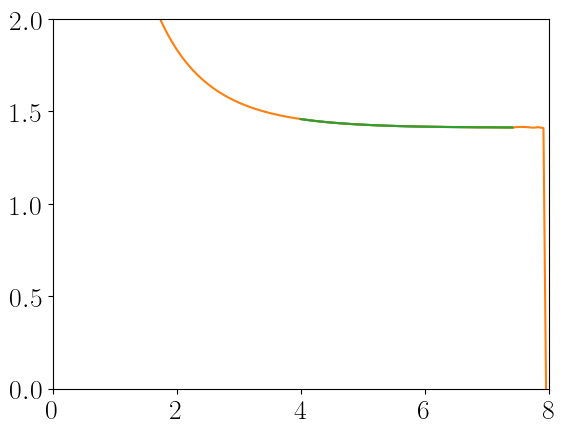

In [65]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [66]:
masses_.append([8, Nt, opt[0][0]])

In [67]:
T=16
Nt=240 # 240

In [68]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

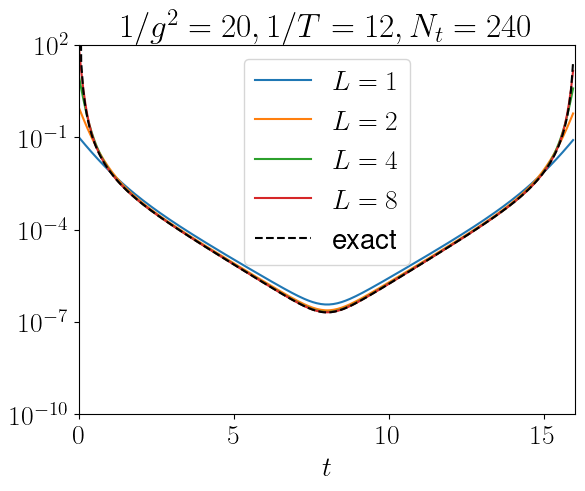

In [69]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [70]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [71]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [72]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

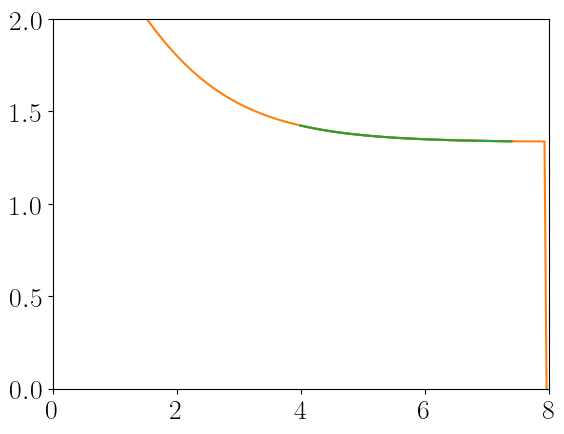

In [73]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [74]:
masses_.append([1, Nt, opt[0][0]])

In [75]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [76]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

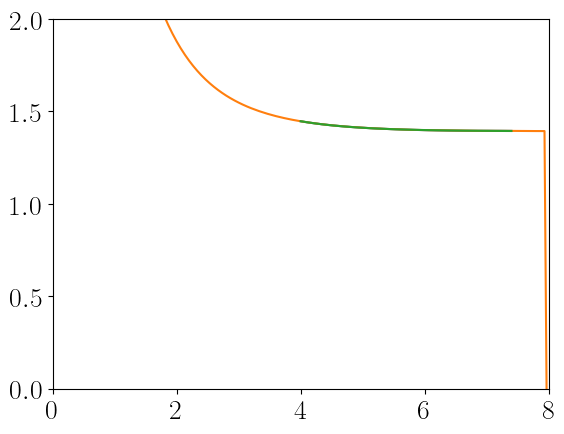

In [77]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [78]:
masses_.append([2, Nt, opt[0][0]])

In [79]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [80]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

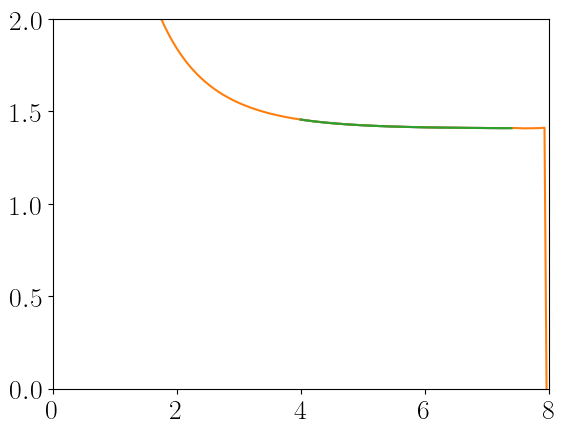

In [81]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [82]:
masses_.append([4, Nt, opt[0][0]])

In [83]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [84]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

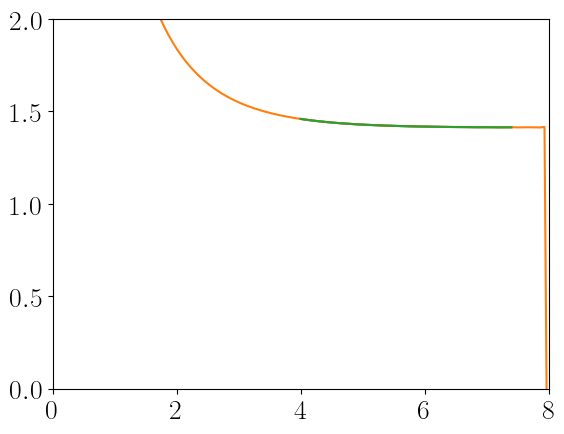

In [85]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [86]:
masses_.append([8, Nt, opt[0][0]])

In [87]:
masses = np.array(masses_)

In [88]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [89]:
masses

array([[  1.        ,  96.        ,   1.33102933],
       [  2.        ,  96.        ,   1.3892001 ],
       [  4.        ,  96.        ,   1.40597917],
       [  8.        ,  96.        ,   1.40947169],
       [  1.        , 144.        ,   1.3326023 ],
       [  2.        , 144.        ,   1.39118791],
       [  4.        , 144.        ,   1.40792916],
       [  8.        , 144.        ,   1.41155641],
       [  1.        , 192.        ,   1.33327297],
       [  2.        , 192.        ,   1.39180334],
       [  4.        , 192.        ,   1.40787165],
       [  8.        , 192.        ,   1.4121424 ],
       [  1.        , 240.        ,   1.33370442],
       [  2.        , 240.        ,   1.39277266],
       [  4.        , 240.        ,   1.4082691 ],
       [  8.        , 240.        ,   1.41280115]])

In [90]:
a_s = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses ])

In [91]:
def fitter( x, c0, c1, c2 ):
    return c0 + c1*x[0]*x[1] + c2*x[0]**2

In [92]:
opt1= sp.optimize.curve_fit( fitter, a_s.T, masses.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [93]:
masses2_ = []
for elem in masses:
    if elem[0]!=1:
        masses2_.append(elem)
masses2=np.array(masses2_)

In [94]:
masses2

array([[  2.        ,  96.        ,   1.3892001 ],
       [  4.        ,  96.        ,   1.40597917],
       [  8.        ,  96.        ,   1.40947169],
       [  2.        , 144.        ,   1.39118791],
       [  4.        , 144.        ,   1.40792916],
       [  8.        , 144.        ,   1.41155641],
       [  2.        , 192.        ,   1.39180334],
       [  4.        , 192.        ,   1.40787165],
       [  8.        , 192.        ,   1.4121424 ],
       [  2.        , 240.        ,   1.39277266],
       [  4.        , 240.        ,   1.4082691 ],
       [  8.        , 240.        ,   1.41280115]])

In [95]:
a_s2 = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses2 ])

In [110]:
opt2= sp.optimize.curve_fit( fitter, a_s2.T, masses2.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [111]:
opt3= sp.optimize.curve_fit( fitter, a_s2[3:].T, masses2[3:].T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [113]:
opt3

(array([ 1.41424303, -0.051593  , -0.05622196]),
 array([[ 5.72390811e-01, -2.53390790e+01,  1.97466674e+00],
        [-2.53390790e+01,  1.95296135e+03, -2.18589015e+02],
        [ 1.97466674e+00, -2.18589015e+02,  3.00663038e+01]]),
 {'fvec': array([ 3.37849883e-05, -4.45151853e-04,  5.56597217e-04,  2.65267048e-04,
          4.15539478e-05,  1.85907476e-04, -1.95910032e-04, -9.83829780e-05,
         -3.43665353e-04]),
  'nfev': 9,
  'fjac': array([[-2.99999999,  0.33333333,  0.33333333,  0.33333333,  0.33333333,
           0.33333333,  0.33333333,  0.33333333,  0.33333333],
         [-0.46147118,  0.42256576,  0.4262152 , -0.34679944,  0.26738368,
           0.4262152 , -0.34679944,  0.26738368,  0.4262152 ],
         [-0.09057515,  0.0472965 ,  0.02262837,  0.191696  ,  0.12834538,
           0.38400114,  0.62695049,  0.34891465,  0.49464954]]),
  'ipvt': array([1, 3, 2], dtype=int32),
  'qtf': array([-1.53954997e-10, -2.50307487e-10, -4.90942677e-09])},
 'Both actual and predicted 

In [114]:
opt1[0][0]

1.414131105433674

In [115]:
masses.T[2][::4]

array([1.33102933, 1.3326023 , 1.33327297, 1.33370442])

In [116]:
a_s[::3].T[0]

array([1.10714872, 0.15022749, 0.29947447, 0.59094644, 1.10714872,
       0.15022749])

In [117]:
a_s[4:8]

array([[1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111]])

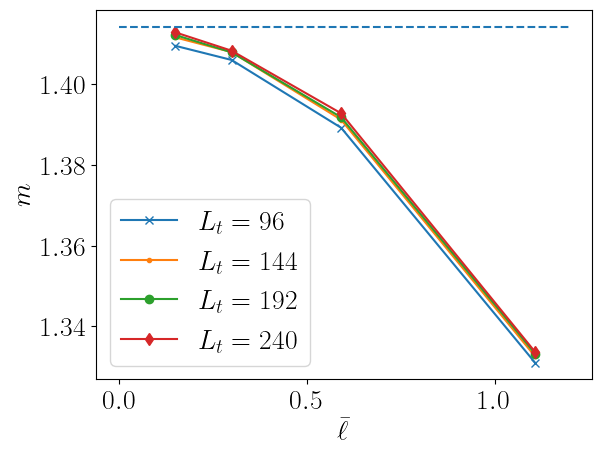

In [123]:
plt.plot( a_s[:4].T[0], masses.T[2][:4], label="$L_t=96$", marker='x' )
plt.plot( a_s[4:8].T[0], masses.T[2][4:8], label="$L_t=144$", marker='.' )
plt.plot( a_s[8:12].T[0], masses.T[2][8:12], label="$L_t=192$", marker='o' )
plt.plot( a_s[12:].T[0], masses.T[2][12:], label="$L_t=240$", marker='d' )

plt.legend()

# xxx=np.linspace( 0.0, 1.2, 100 )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[0][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=96$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[4][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=144$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[7][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=192$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[10][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=240$", ls='dotted' )

plt.hlines( np.sqrt(2.0), 0.0, 1.2, ls='dashed' )

plt.xlabel("$\\bar{\\ell}$")
plt.ylabel("$m$")

plt.savefig("m_ellbar.pdf", bbox_inches="tight")

In [125]:
a_s[0][1]

0.16666666666666666